In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "ndv[jupyter,vispy]",
#     "jupyter-rfb<=0.5.4",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
# ]
# ///

In [2]:
# specify dependencies
import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.morphology import binary_closing, disk, remove_small_objects
from skimage.segmentation import watershed

In [3]:
image_path = "../../../_static/images/classic_seg/DAPI_wf_0.tif"
raw_image = tifffile.imread(image_path)
print(raw_image.shape, raw_image.dtype)

(2304, 2304) float32


In [ ]:
ndv.imshow(raw_image)

In [4]:
viewer = ndv.imshow(raw_image)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


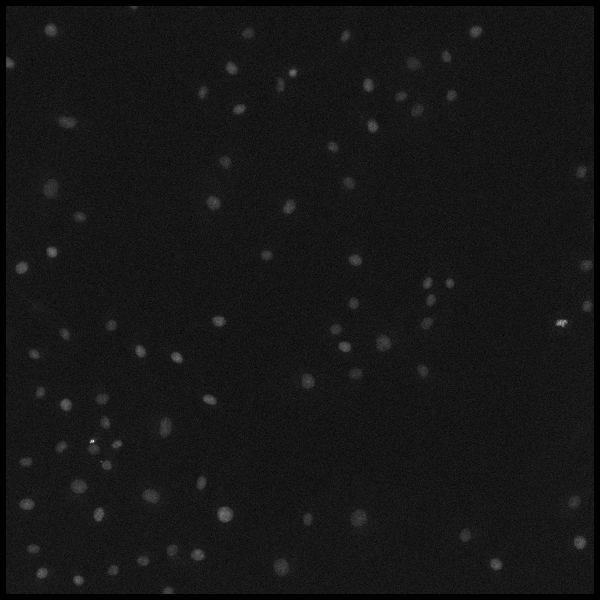

In [5]:
viewer.widget().children[1].snapshot()

In [6]:
filtered_image = gaussian(raw_image, sigma=1)

In [ ]:
ndv.imshow(filtered_image)

In [7]:
viewer = ndv.imshow(filtered_image)

RFBOutputContext()

<IPython.core.display.Javascript object>


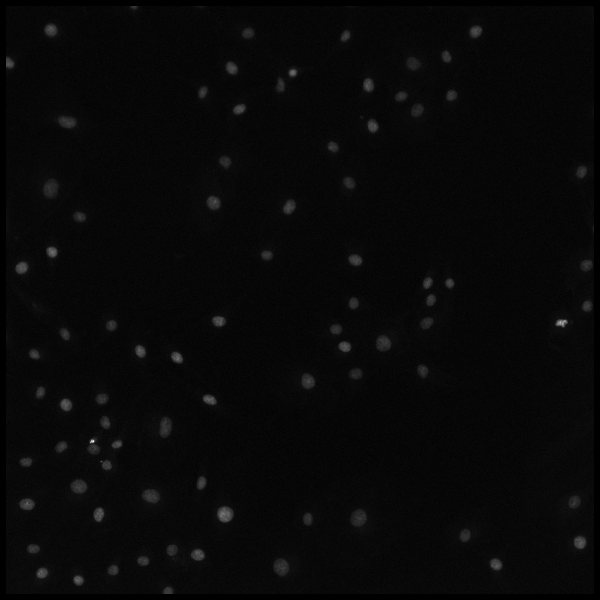

In [8]:
viewer.widget().children[1].snapshot()

In [9]:
threshold = threshold_otsu(filtered_image)

In [10]:
binary_mask = filtered_image > threshold
print(np.max(binary_mask))  # binary_mask max value
print(np.min(binary_mask))  # binary_mask min value

True
False


In [11]:
def double_image_plotter(img_1: np.ndarray, img_2: np.ndarray) -> None:
    """Function that plots 2 images side by side with their variable names as titles

    Parameters
    ----------
    img_1: np.ndarray
    left plotted image

    img_2: np.ndarray
    right plotted image

    Return
    ----------
    None: plot of the images

    """
    # Create a figure and axis
    fig, axes = plt.subplots(1, 2, figsize=(8, 6), layout="constrained")  # 1 row, 2 columns

    # Plot images
    axes[0].imshow(img_1, cmap="gray", vmin=img_1.min(), vmax=img_1.max())
    axes[0].axis("off")  # Turn off axis
    axes[1].imshow(img_2, cmap="gray", vmin=img_2.min(), vmax=img_2.max())
    axes[1].axis("off")  # Turn off axis

    # Show the plot
    plt.show()

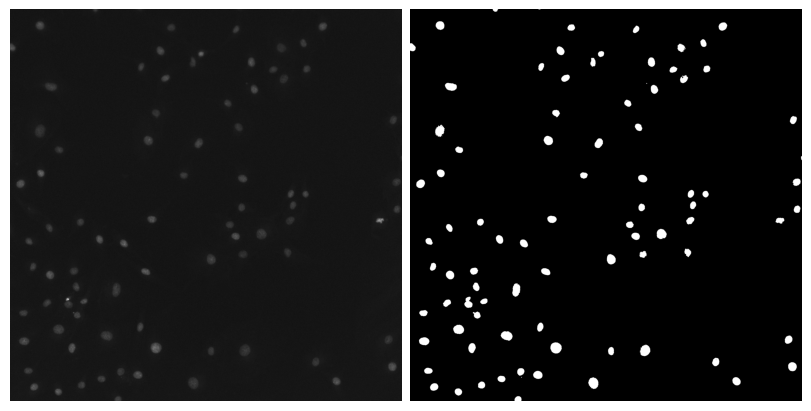

In [12]:
double_image_plotter(raw_image, binary_mask)

In [13]:
labeled_image = label(binary_mask)

In [14]:
seg_summary = label2rgb(labeled_image, image=raw_image)

/home/runner/work/bobiac-book/bobiac-book/.venv/lib/python3.12/site-packages/skimage/color/colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08745135366916656..1.4824706792831421].


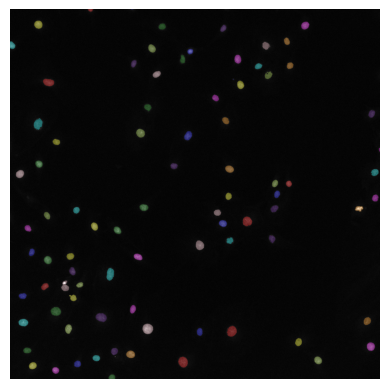

In [15]:
plt.imshow(seg_summary)
plt.axis("off")  # Turn off axis
plt.show()

In [16]:
binary_mask_sized = remove_small_objects(binary_mask, min_size=10)

/tmp/ipykernel_3172/2564569088.py:1: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_mask_sized = remove_small_objects(binary_mask, min_size=10)


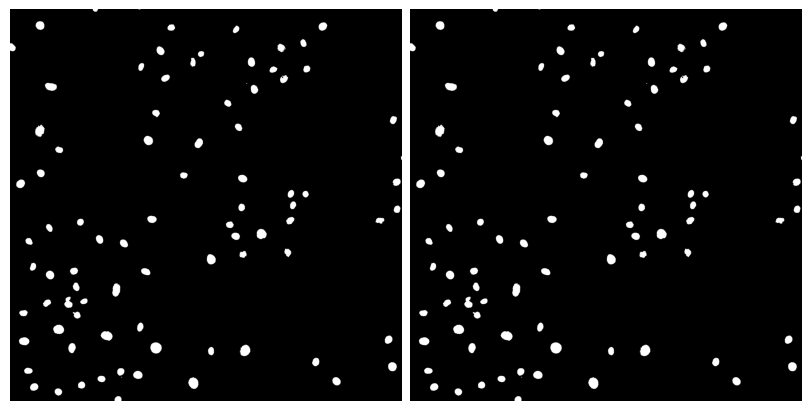

In [17]:
double_image_plotter(binary_mask, binary_mask_sized)

In [18]:
binary_mask_filled = binary_closing(binary_mask_sized, disk(5))

/tmp/ipykernel_3172/3986192061.py:1: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  binary_mask_filled = binary_closing(binary_mask_sized, disk(5))


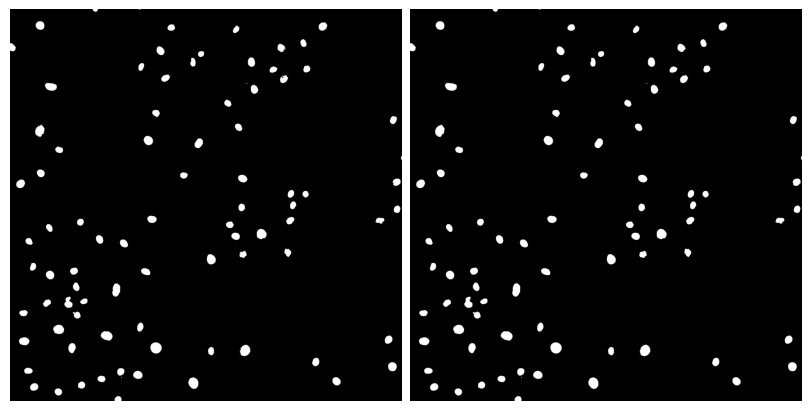

In [19]:
double_image_plotter(binary_mask_sized, binary_mask_filled)

In [20]:
# compute the distance transform
distance_transform = distance_transform_edt(binary_mask_filled)

In [21]:
# find local maxima coordinates in the distance transform
local_maxima_coords = peak_local_max(
    distance_transform, footprint=np.ones((25, 25)), min_distance=10
)
print(local_maxima_coords)

[[1992  859]
 [2195 1078]
 [2007 1383]
 [1321 1478]
 [1882  286]
 [1920  571]
 [ 772  814]
 [ 713  175]
 [1472 1183]
 [2102 2249]
 [  95  177]
 [2150  753]
 [1561  235]
 [1027   61]
 [1952   82]
 [ 100 1840]
 [2186 1919]
 [ 995 1368]
 [1639  626]
 [1650  626]
 [ 457  246]
 [ 965  182]
 [2221  141]
 [1941 2228]
 [1990  364]
 [ 311 1420]
 [ 474 1438]
 [1235  832]
 [1335 1330]
 [ 243  884]
 [ 789 1110]
 [1016 2274]
 [ 226 1594]
 [2250  284]
 [1351  526]
 [1375  668]
 [2131  651]
 [2074 1799]
 [1734  341]
 [2210  421]
 [1540  374]
 [ 412 1608]
 [ 350 1746]
 [1165 1362]
 [1252  413]
 [ 610  860]
 [1267 1294]
 [1542  797]
 [ 693 1344]
 [1799  394]
 [ 404  914]
 [ 649 2255]
 [2174  539]
 [ 106  950]
 [1174 2277]
 [1868  766]
 [1083 1653]
 [1633  388]
 [1241 1648]
 [1364  110]
 [ 977 1020]
 [1428 1633]
 [ 552 1281]
 [1087 1738]
 [ 826  287]
 [1150 1665]
 [1787   83]
 [2007 1182]
 [2125  104]
 [ 353 1549]
 [1725  218]
 [1442 1370]
 [1283  230]
 [ 198 1725]
 [ 262 1124]
 [1514  136]
 [ 336  771]

In [22]:
# create image that's the same size and dtype as binary_mask_filled
local_maxima_image = np.zeros_like(binary_mask_filled, dtype=bool)

In [23]:
print(local_maxima_coords.T)

[[1992 2195 2007 1321 1882 1920  772  713 1472 2102   95 2150 1561 1027
  1952  100 2186  995 1639 1650  457  965 2221 1941 1990  311  474 1235
  1335  243  789 1016  226 2250 1351 1375 2131 2074 1734 2210 1540  412
   350 1165 1252  610 1267 1542  693 1799  404  649 2174  106 1174 1868
  1083 1633 1241 1364  977 1428  552 1087  826 1150 1787 2007 2125  353
  1725 1442 1283  198  262 1514  336 1717  316 1241  115 1707  435 2165]
 [ 859 1078 1383 1478  286  571  814  175 1183 2249  177  753  235   61
    82 1840 1919 1368  626  626  246  182  141 2228  364 1420 1438  832
  1330  884 1110 2274 1594  284  526  668  651 1799  341  421  374 1608
  1746 1362  413  860 1294  797 1344  394  914 2255  539  950 2277  766
  1653  388 1648  110 1020 1633 1281 1738  287 1665   83 1182  104 1549
   218 1370  230 1725 1124  136  771  437 1076 2179 1333  339 1391  655]]


In [24]:
print(tuple(local_maxima_coords.T))

(array([1992, 2195, 2007, 1321, 1882, 1920,  772,  713, 1472, 2102,   95,
       2150, 1561, 1027, 1952,  100, 2186,  995, 1639, 1650,  457,  965,
       2221, 1941, 1990,  311,  474, 1235, 1335,  243,  789, 1016,  226,
       2250, 1351, 1375, 2131, 2074, 1734, 2210, 1540,  412,  350, 1165,
       1252,  610, 1267, 1542,  693, 1799,  404,  649, 2174,  106, 1174,
       1868, 1083, 1633, 1241, 1364,  977, 1428,  552, 1087,  826, 1150,
       1787, 2007, 2125,  353, 1725, 1442, 1283,  198,  262, 1514,  336,
       1717,  316, 1241,  115, 1707,  435, 2165]), array([ 859, 1078, 1383, 1478,  286,  571,  814,  175, 1183, 2249,  177,
        753,  235,   61,   82, 1840, 1919, 1368,  626,  626,  246,  182,
        141, 2228,  364, 1420, 1438,  832, 1330,  884, 1110, 2274, 1594,
        284,  526,  668,  651, 1799,  341,  421,  374, 1608, 1746, 1362,
        413,  860, 1294,  797, 1344,  394,  914, 2255,  539,  950, 2277,
        766, 1653,  388, 1648,  110, 1020, 1633, 1281, 1738,  287, 1665,

In [25]:
# add the local_maxima_coords to the created local_maxima image
local_maxima_image[tuple(local_maxima_coords.T)] = True

In [26]:
# find local maxima coordinates in the distance transform
local_maxima_coords = peak_local_max(
    distance_transform, footprint=np.ones((25, 25)), min_distance=10
)

# create image that's the same size and dtype as binary_mask_filled
local_maxima_image = np.zeros_like(binary_mask_filled, dtype=bool)

# add the local_maxima_coords to the created local_maxima image
local_maxima_image[tuple(local_maxima_coords.T)] = True

# label the local_maxima image to create seeds for the watershed function
seeds = label(local_maxima_image)

In [27]:
# apply the watershed algorithm to segment the image and get labels
labeled_ws_image = watershed(-distance_transform, seeds, mask=binary_mask_filled)

In [28]:
seg_summary_refined = label2rgb(labeled_ws_image, image=raw_image, bg_label=0)

/home/runner/work/bobiac-book/bobiac-book/.venv/lib/python3.12/site-packages/skimage/color/colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08745135366916656..1.4824706792831421].


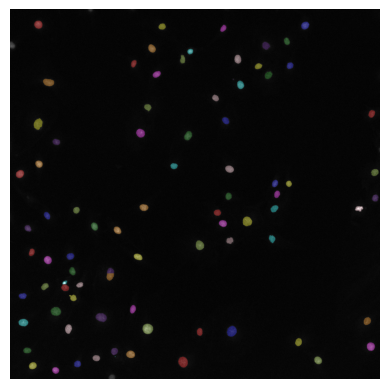

In [29]:
plt.imshow(seg_summary_refined)
plt.axis("off")  # Turn off axis
plt.show()

/tmp/ipykernel_3172/1851959794.py:25: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_mask_sized = remove_small_objects(binary_mask, min_size=10)
/tmp/ipykernel_3172/1851959794.py:28: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  binary_mask_filled = binary_closing(binary_mask_sized)


/home/runner/work/bobiac-book/bobiac-book/.venv/lib/python3.12/site-packages/skimage/color/colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08745135366916656..1.4824706792831421].


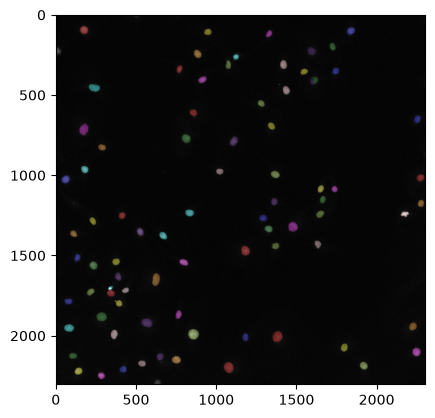

In [30]:
# specify dependencies
import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.morphology import binary_closing, remove_small_objects
from skimage.segmentation import watershed

# load the image
image_path = "../../../_static/images/classic_seg/DAPI_wf_0.tif"
raw_image = tifffile.imread(image_path)

# filter the image with gaussian filter
filtered_image = gaussian(raw_image, sigma=1)

# threshold filtered_image to generate binary mask
binary_mask = filtered_image > threshold_otsu(filtered_image)

# Remove small objects
binary_mask_sized = remove_small_objects(binary_mask, min_size=10)

# Fill small holes by performing morphological closing
binary_mask_filled = binary_closing(binary_mask_sized)

# apply watershed to separate nuclei and label mask
# compute the distance transform
distance_transform = distance_transform_edt(binary_mask_filled)

# find local maxima coordinates in the distance transform
local_maxima_coords = peak_local_max(
    distance_transform, footprint=np.ones((25, 25)), min_distance=10
)

# create image that's the same size and dtype as binary_mask_filled
local_maxima_image = np.zeros_like(binary_mask_filled, dtype=bool)

# add the local_maxima_coords to the created local_maxima image
local_maxima_image[tuple(local_maxima_coords.T)] = True

# label the local_maxima image to create seeds for the watershed function
seeds = label(local_maxima_image)

# apply the watershed algorithm to segment the image and get labels
labeled_ws_image = watershed(-distance_transform, seeds, mask=binary_mask_filled)

# visualize the segmentation result
seg_summary_refined = label2rgb(labeled_ws_image, image=raw_image, bg_label=0)
plt.imshow(seg_summary_refined)
plt.show()

In [31]:
from pathlib import Path

folder_dir = Path("../../../_static/images/classic_seg/")
for image_path in folder_dir.iterdir():
    print(image_path)

../../../_static/images/classic_seg/DAPI_wf_0.tif
../../../_static/images/classic_seg/seg_methods_classic.png


In [32]:
from pathlib import Path

folder_dir = Path("../../../_static/images/classic_seg/")
for image_path in folder_dir.glob("*.tif"):  # only loop through files ending in .tif
    print(image_path)

../../../_static/images/classic_seg/DAPI_wf_0.tif


In [ ]:
from pathlib import Path

import ndv
import numpy as np
import tifffile
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.morphology import binary_closing, remove_small_objects
from skimage.segmentation import watershed

folder_dir = Path("../../../_static/images/classic_seg/")

for image_path in folder_dir.glob("*.tif"):  # only loop through files ending in .tif
    # load the image
    raw_image = tifffile.imread(image_path)

    # filter the image with gaussian filter
    filtered_image = gaussian(raw_image, sigma=1)

    # threshold filtered_image to generate binary mask
    binary_mask = filtered_image > threshold_otsu(filtered_image)

    # Remove small objects
    binary_mask_sized = remove_small_objects(binary_mask, min_size=10)

    # Fill small holes by performing morphological closing
    binary_mask_filled = binary_closing(binary_mask_sized)

    # apply watershed to separate nuclei and label mask
    # compute the distance transform
    distance_transform = distance_transform_edt(binary_mask_filled)

    # find local maxima coordinates in the distance transform
    local_maxima_coords = peak_local_max(
        distance_transform, footprint=np.ones((25, 25)), min_distance=10
    )

    # create image that's the same size and dtype as binary_mask_filled
    local_maxima_image = np.zeros_like(binary_mask_filled, dtype=bool)

    # add the local_maxima_coords to the created local_maxima image
    local_maxima_image[tuple(local_maxima_coords.T)] = True

    # label the local_maxima image to create seeds for the watershed function
    seeds = label(local_maxima_image)

    # apply the watershed algorithm to segment the image and get labels
    labeled_ws_image = watershed(-distance_transform, seeds, mask=binary_mask_filled)

    # visualize the segmentation result
    seg_summary_refined = label2rgb(labeled_ws_image, image=raw_image, bg_label=0)
    plt.imshow(seg_summary_refined)
    plt.show()

    break

In [33]:
folder_dir = Path("../../../_static/images/classic_seg/")
for image_path in folder_dir.glob("*.tif"):  # only loop through files ending in .tif
    print(image_path.stem)  # file name, without .tif at the end

DAPI_wf_0


In [ ]:
from pathlib import Path

import numpy as np
import tifffile
from scipy.ndimage import distance_transform_edt
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.morphology import binary_closing, remove_small_objects
from skimage.segmentation import watershed

input_dir = Path("../../../_static/images/classic_seg/")
output_dir = Path("../../../_static/images/classic_seg/")

for image_path in input_dir.glob("*.tif"):  # only loop through files ending in .tif
    # load the image
    raw_image = tifffile.imread(image_path)

    # filter the image with gaussian filter
    filtered_image = gaussian(raw_image, sigma=1)

    # threshold filtered_image to generate binary mask
    binary_mask = filtered_image > threshold_otsu(filtered_image)

    # Remove small objects
    binary_mask_sized = remove_small_objects(binary_mask, min_size=10)

    # Fill small holes by performing morphological closing
    binary_mask_filled = binary_closing(binary_mask_sized)

    # apply watershed to separate nuclei and label mask
    # compute the distance transform
    distance_transform = distance_transform_edt(binary_mask_filled)

    # find local maxima coordinates in the distance transform
    local_maxima_coords = peak_local_max(
        distance_transform, footprint=np.ones((25, 25)), min_distance=10
    )

    # create image that's the same size and dtype as binary_mask_filled
    local_maxima_image = np.zeros_like(binary_mask_filled, dtype=bool)

    # add the local_maxima_coords to the created local_maxima image
    local_maxima_image[tuple(local_maxima_coords.T)] = True

    # label the local_maxima image to create seeds for the watershed function
    seeds = label(local_maxima_image)

    # apply the watershed algorithm to segment the image and get labels
    labeled_ws_image = watershed(-distance_transform, seeds, mask=binary_mask_filled)

    # visualize the segmentation result
    seg_summary_refined = label2rgb(labeled_ws_image, image=raw_image, bg_label=0)
    plt.imshow(seg_summary_refined)
    plt.show()

    # save labeled_ws_image
    output_filename = output_dir / f"{image_path.stem}_labeled.tif"
    tifffile.imwrite(output_filename, labeled_ws_image.astype("uint32"))

    break